# Historical GBM calibration & scenario paths

SQLite → correlation heatmap / vol bars. CSV from `exports/` → multifactor path fans.

- DB: repo `db.sqlite3` or `NUMERAIRE_DB_PATH` / `.env`
- Scenarios: `exports/{BOOK}_{valuation_as_of}_all_factors.csv` (from `dev_main --simulate` + `NUMERAIRE_DUMP_SCENARIOS`)

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt

from numeraire_viz import (
    default_db_path,
    default_exports_dir,
    list_calibration_dates,
    list_scenario_exports,
    load_historical_calibration,
    correlation_matrix_from_sparse,
    plot_calibration_overview,
    plot_correlation_heatmap,
    plot_factor_volatility_bars,
    load_scenario_paths,
    plot_scenario_paths,
    plot_scenario_paths_grid,
    plot_terminal_distribution,
)

print("DB:", default_db_path())
print("exports:", default_exports_dir())
print("scenario files:", [p.name for p in list_scenario_exports()])

DB: /opt/numeraire/dev/db.sqlite3
exports: /opt/numeraire/dev/exports
scenario files: ['BOOK_1_2026-06-15_all_factors.csv']


In [2]:
# --- parameters ---
SCOPE_KEY = "BOOK_1"
VALUATION_AS_OF = "2026-06-15"  # simulate / valuation date
MAX_PATHS_PLOT = 10  # cap lines on charts (export may have more)

calib_dates = list_calibration_dates(SCOPE_KEY)
print(f"Calibration dates for {SCOPE_KEY} ({len(calib_dates)}):", calib_dates)

header, factors, corr_sparse = load_historical_calibration(
    SCOPE_KEY,
    valuation_as_of=VALUATION_AS_OF,
)
print(
    f"Using calibration_id={header['calibration_id']} as_of={header['as_of']} "
    f"factors={header['num_factors']}"
)
factors

Calibration dates for BOOK_1 (1): ['2026-06-01']
Using calibration_id=3 as_of=2026-06-01 factors=5


,factor_index,underlying_id,spot_as_of,volatility
0,0,AAPL,306.310000,0.304584
1,1,GOOGL,376.370000,0.319044
2,2,MSFT,460.520000,0.273763
3,3,NDX,30513.861601,0.222983
4,4,NVDA,224.360000,0.465906


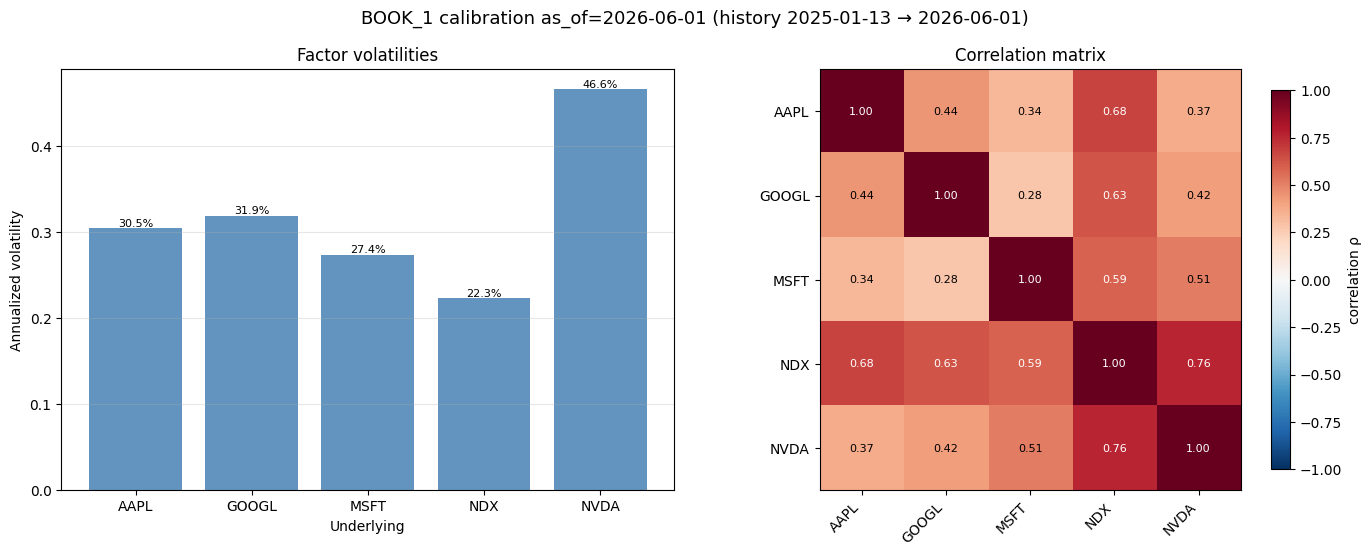

In [3]:
matrix, labels = correlation_matrix_from_sparse(factors, corr_sparse)

plot_calibration_overview(header, factors, matrix, labels)
plt.show()

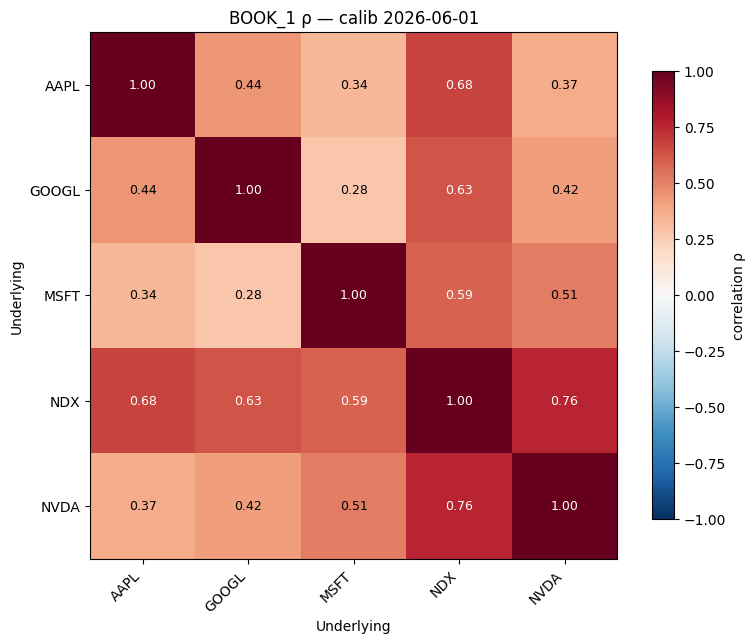

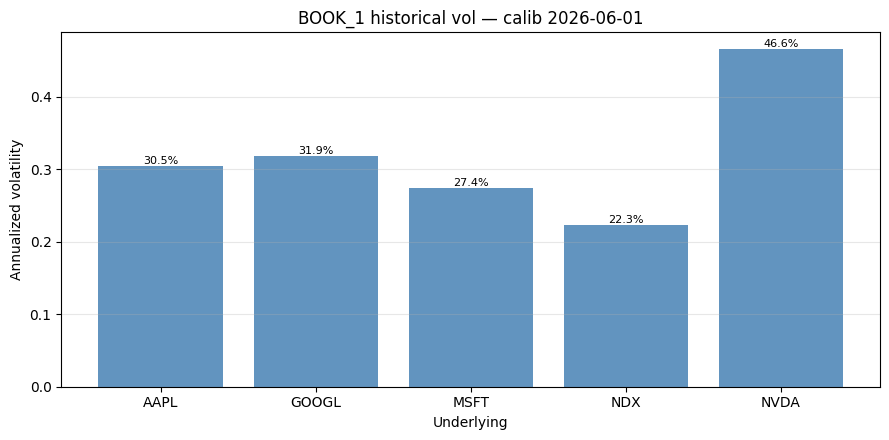

In [4]:
plot_correlation_heatmap(matrix, labels, title=f"{SCOPE_KEY} ρ — calib {header['as_of']}")
plt.show()

plot_factor_volatility_bars(factors, title=f"{SCOPE_KEY} historical vol — calib {header['as_of']}")
plt.show()

In [5]:
scenarios = load_scenario_paths(scope_key=SCOPE_KEY, valuation_as_of=VALUATION_AS_OF)
print(scenarios.groupby("underlying_id").agg(paths=("path", "nunique"), steps=("step", "nunique")))
scenarios.head(8)

               paths  steps
underlying_id              
AAPL              10     14
GOOGL             10     14
MSFT              10     14
NDX               10     14
NVDA              10     14


,path,factor,underlying_id,step,year_fraction,value
0,0,0,AAPL,0,0.000000,306.310000
1,0,0,AAPL,1,0.019178,323.189426
2,0,0,AAPL,2,0.038356,336.023579
3,0,0,AAPL,3,0.057534,329.406958
4,0,0,AAPL,4,0.082192,330.038223
5,0,0,AAPL,5,0.123288,325.330553
6,0,0,AAPL,6,0.164384,334.558737
7,0,0,AAPL,7,0.246575,333.815321


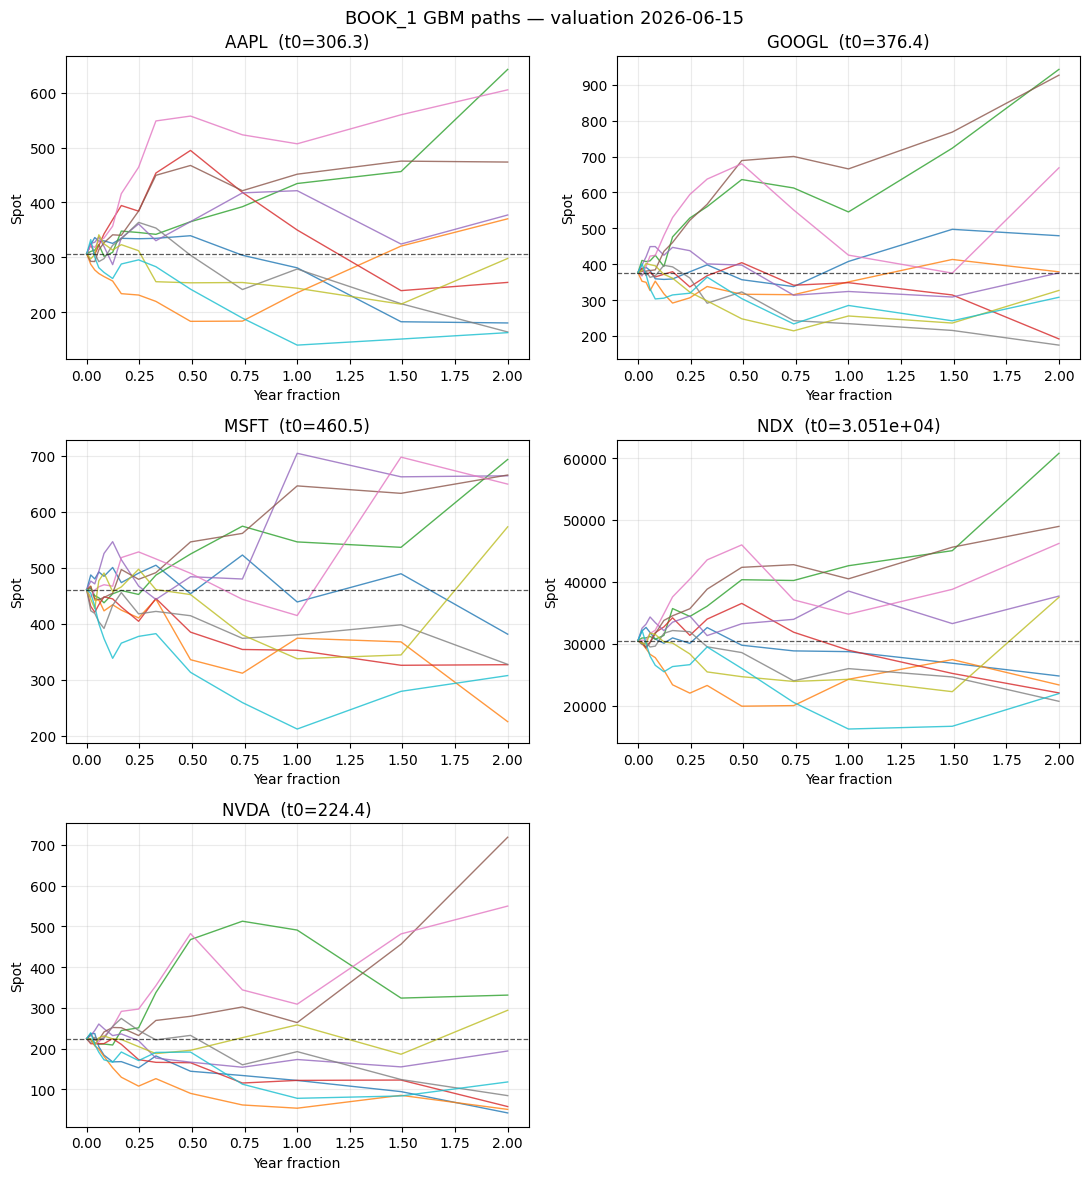

In [6]:
plot_scenario_paths_grid(
    scenarios,
    max_paths=MAX_PATHS_PLOT,
    title=f"{SCOPE_KEY} GBM paths — valuation {VALUATION_AS_OF}",
)
plt.show()

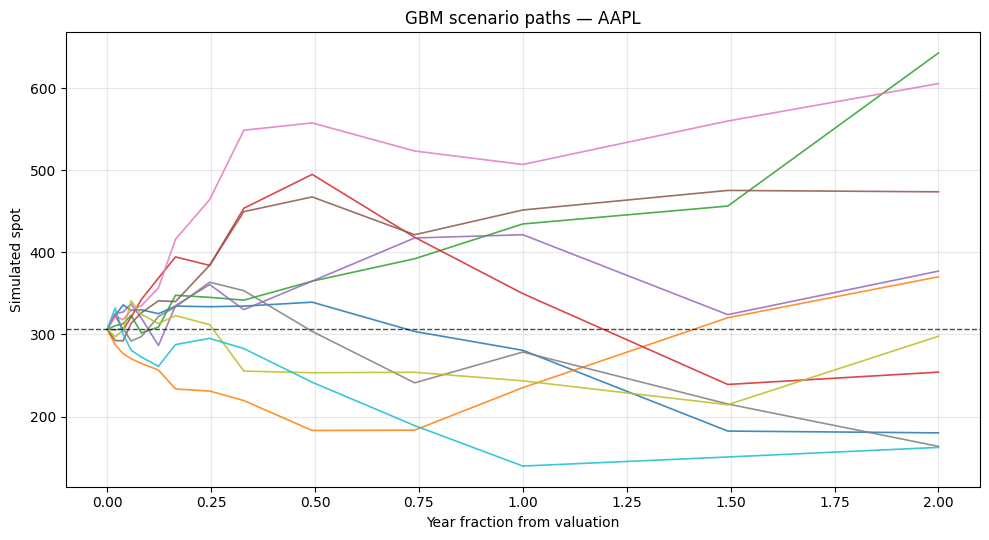

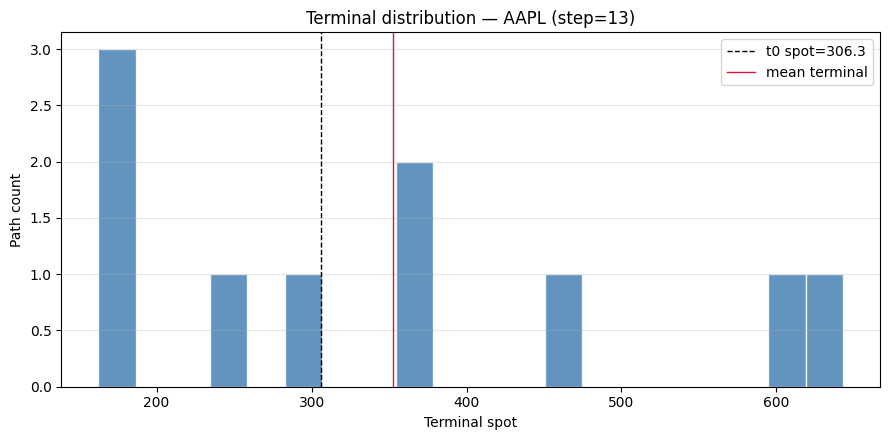

In [7]:
# Single underlying zoom (first in book)
uid = scenarios["underlying_id"].iloc[0]
plot_scenario_paths(scenarios, underlying_id=uid, max_paths=MAX_PATHS_PLOT)
plt.show()

plot_terminal_distribution(scenarios, underlying_id=uid)
plt.show()

In [8]:
# Sanity: t0 must equal calibrated spot on every path
t0 = scenarios[scenarios["step"] == 0].drop_duplicates(["underlying_id", "path"])
spots = factors.set_index("underlying_id")["spot_as_of"]
check = t0.groupby("underlying_id")["value"].agg(["min", "max"]).join(spots.rename("calibrated"))
check["ok"] = (check["min"] - check["calibrated"]).abs() < 1e-6
check

,min,max,calibrated,ok
underlying_id,,,,
AAPL,306.310000,306.310000,306.310000,True
GOOGL,376.370000,376.370000,376.370000,True
MSFT,460.520000,460.520000,460.520000,True
NDX,30513.861601,30513.861601,30513.861601,True
NVDA,224.360000,224.360000,224.360000,True
